In [10]:
# ============================================================
# BESİN KOMPOZİSYONU → KALORİ TAHMİNİ (AutoML Regresyon)
# ✅ Data Leakage Korumalı (sklearn Pipeline)
# ✅ Cross-Validation Pipeline içinde
# ✅ Hyperparameter Search (GridSearchCV)
# ============================================================
 
import os
import glob
import warnings
import pandas as pd
import numpy as np
import kagglehub
 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, KFold
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
 
warnings.filterwarnings("ignore")
 
print("=" * 70)
print("Besin Kompozisyonu → Kalori Tahmini (AutoML | Pipeline)")
print("=" * 70)
 
# ============================================================
# 1️⃣  VERİYİ İNDİR VE YÜKLE
# ============================================================
print("\n[1/9] Veri setleri indiriliyor...")
 
# Turkish Market Sales Dataset
print("\n📦 Turkish Market Sales Dataset indiriliyor...")
market_path = kagglehub.dataset_download(
    "omercolakoglu/turkish-market-sales-dataset-with-9000items"
)
market_files = glob.glob(os.path.join(market_path, "**/*.xls*"), recursive=True)
if not market_files:
    raise FileNotFoundError("Market verisi bulunamadı!")
 
print(f"✅ Okunuyor: {os.path.basename(market_files[0])}")
df_market = pd.read_excel(market_files[0])
print(f"Market verisi: {len(df_market):,} satır")
 
# Food Nutrition Dataset
print("\n🥗 Food Nutrition Dataset indiriliyor...")
nutrition_path = kagglehub.dataset_download("openfoodfacts/world-food-facts")
 
nutrition_files = (
    glob.glob(os.path.join(nutrition_path, "**/*.csv"), recursive=True)
    + glob.glob(os.path.join(nutrition_path, "**/*.tsv"), recursive=True)
    + glob.glob(os.path.join(nutrition_path, "**/*.txt"), recursive=True)
)
 
if not nutrition_files:
    raise FileNotFoundError("Nutrition verisi bulunamadı!")
 
nutrition_files.sort(key=lambda x: os.path.getsize(x), reverse=True)
selected_file = nutrition_files[0]
print(f"✅ Okunuyor: {os.path.basename(selected_file)}")
print(f"   Dosya boyutu: {os.path.getsize(selected_file) / 1024 / 1024:.1f} MB")
 
cols_to_use = [
    "product_name", "energy_100g", "fat_100g",
    "carbohydrates_100g", "proteins_100g",
    "sugars_100g", "salt_100g", "fiber_100g",
]
 
with open(selected_file, "r", encoding="utf-8", errors="ignore") as f:
    first_line = f.readline()
separator = "\t" if "\t" in first_line else ","
 
df_nutrition = pd.read_csv(
    selected_file,
    usecols=lambda x: x in cols_to_use,
    sep=separator,
    low_memory=False,
    on_bad_lines="skip",
    encoding="utf-8",
)
print(f"Nutrition verisi: {len(df_nutrition):,} satır")


Besin Kompozisyonu → Kalori Tahmini (AutoML | Pipeline)

[1/9] Veri setleri indiriliyor...

📦 Turkish Market Sales Dataset indiriliyor...
✅ Okunuyor: MarketSales.xlsx
Market verisi: 611,108 satır

🥗 Food Nutrition Dataset indiriliyor...
✅ Okunuyor: en.openfoodfacts.org.products.tsv
   Dosya boyutu: 963.5 MB
Nutrition verisi: 356,027 satır


In [11]:
# ============================================================
# 2️⃣  VERİ TEMİZLİĞİ VE BİRLEŞTİRME
# ============================================================
print("\n[2/9] Veri temizleme ve birleştirme...")
 
df_market.rename(columns={"ITEMNAME": "product_name"}, inplace=True)
market_products = df_market[["product_name"]].drop_duplicates()
print(f"Market'te benzersiz ürün: {len(market_products):,}")
 
# Hedef ve kritik özellik NaN satırlarını düşür
df_nutrition = df_nutrition.dropna(
    subset=["energy_100g", "fat_100g", "carbohydrates_100g", "proteins_100g"]
)
 
# Fiziksel olarak imkansız değerleri temizle
df_nutrition = df_nutrition[
    (df_nutrition["energy_100g"] > 0) & (df_nutrition["energy_100g"] < 1000)
    & (df_nutrition["fat_100g"] >= 0) & (df_nutrition["fat_100g"] <= 100)
    & (df_nutrition["carbohydrates_100g"] >= 0) & (df_nutrition["carbohydrates_100g"] <= 100)
    & (df_nutrition["proteins_100g"] >= 0) & (df_nutrition["proteins_100g"] <= 100)
].copy()
print(f"Temizlenmiş nutrition verisi: {len(df_nutrition):,} satır")
 
# Ürün adı eşleştirmesi
df_nutrition["product_name_lower"] = df_nutrition["product_name"].str.lower().str.strip()
market_products = market_products.copy()
market_products["product_name_lower"] = market_products["product_name"].str.lower().str.strip()
 
df_combined = market_products.merge(df_nutrition, on="product_name_lower", how="inner")
print(f"Birleştirilmiş veri: {len(df_combined):,} ürün")
 
if len(df_combined) < 1000:
    print("⚠️  Az eşleşme → tüm nutrition verisi kullanılacak")
    df_combined = df_nutrition.copy()
 
# ============================================================
# 3️⃣  HEDEF + HAM ÖZELLİKLERİ AYIR  →  TRAIN / TEST BÖLE
#      ⚠️  Feature Engineering BU NOKTADAN SONRA, Pipeline içinde!
# ============================================================
print("\n[3/9] Train / Test bölme (feature engineering öncesi)...")
 
RAW_FEATURES = [
    "fat_100g", "carbohydrates_100g", "proteins_100g",
    "sugars_100g", "salt_100g", "fiber_100g",
]
 
# Ham özellikleri al — NaN'ları 0 ile doldur (gerçek değerleri bozmaz)
X_raw = df_combined[RAW_FEATURES].fillna(0).values
y     = df_combined["energy_100g"].values
 
# ✅ ÖNCE böl — hiçbir fit/transform daha önce yapılmadı
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train_raw.shape[0]:,} | Test: {X_test_raw.shape[0]:,}")
 
 
# ============================================================
# 4️⃣  CUSTOM TRANSFORMER — Feature Engineering (sızdırmaz)
# ============================================================
from sklearn.base import BaseEstimator, TransformerMixin
 
class NutritionFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Ham besin değerlerinden türetilmiş özellikler ekler.
    Pipeline içinde olduğu için fit/transform yalnızca
    ilgili fold verisine uygulanır → Data Leakage YOK.
 
    Sütun sırası (X girişi):
        0: fat | 1: carb | 2: protein | 3: sugar | 4: salt | 5: fiber
    """
    def fit(self, X, y=None):
        return self  # stateless transform — fit gerekmez
 
    def transform(self, X):
        fat   = X[:, 0]
        carb  = X[:, 1]
        prot  = X[:, 2]
        sugar = X[:, 3]
        salt  = X[:, 4]
        fiber = X[:, 5]
        eps   = 1e-6  # sıfıra bölünmeyi önle
 
        total  = fat + carb + prot
        f_rat  = fat   / (total + eps)
        c_rat  = carb  / (total + eps)
        p_rat  = prot  / (total + eps)
        s2c    = sugar / (carb  + eps)
 
        # ⛔ theoretical_energy EKLENMİYOR → bu target'ı doğrudan türetir
        #    (en klasik data leakage örneği)
        return np.column_stack([
            fat, carb, prot, sugar, salt, fiber,
            total, f_rat, c_rat, p_rat, s2c,
        ])
 
FEATURE_NAMES = [
    "fat_100g", "carbohydrates_100g", "proteins_100g",
    "sugars_100g", "salt_100g", "fiber_100g",
    "total_macros", "fat_ratio", "carb_ratio", "protein_ratio",
    "sugar_to_carb",
]



[2/9] Veri temizleme ve birleştirme...
Market'te benzersiz ürün: 9,304
Temizlenmiş nutrition verisi: 118,986 satır
Birleştirilmiş veri: 1,445 ürün

[3/9] Train / Test bölme (feature engineering öncesi)...
Train: 1,156 | Test: 289


In [12]:
# ============================================================
# 5️⃣  AUTOML — Pipeline + GridSearchCV
#      Scaler ve feature engineering Pipeline içinde →
#      cross-validation sırasında da sızdırma yok ✅
# ============================================================
print("\n[4/9] AutoML Pipeline'lar tanımlanıyor...")
 
def build_pipeline(estimator):
    return Pipeline([
        ("fe",     NutritionFeatureEngineer()),
        ("scaler", StandardScaler()),
        ("model",  estimator),
    ])
 
# Her model için arama uzayı
search_configs = {
    "Ridge": {
        "pipeline": build_pipeline(Ridge()),
        "params":   {"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    },
    "Lasso": {
        "pipeline": build_pipeline(Lasso(max_iter=2000)),
        "params":   {"model__alpha": [0.001, 0.01, 0.1, 1.0]},
    },
    "ElasticNet": {
        "pipeline": build_pipeline(ElasticNet(max_iter=2000)),
        "params": {
            "model__alpha":    [0.01, 0.1, 1.0],
            "model__l1_ratio": [0.2, 0.5, 0.8],
        },
    },
    "RandomForest": {
        "pipeline": build_pipeline(
            RandomForestRegressor(random_state=42, n_jobs=-1)
        ),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth":    [10, 15, None],
        },
    },
    "GradientBoosting": {
        "pipeline": build_pipeline(
            GradientBoostingRegressor(random_state=42)
        ),
        "params": {
            "model__n_estimators":  [100, 200],
            "model__max_depth":     [3, 5],
            "model__learning_rate": [0.05, 0.1],
        },
    },
}
 
# ============================================================
# 6️⃣  EĞİTİM + HYPERparameter SEARCH
# ============================================================
print("\n[5/9] GridSearchCV ile model eğitimi başlıyor...\n")
 
# KFold nesnesi — CV boyunca tutarlı fold'lar
cv = KFold(n_splits=5, shuffle=True, random_state=42)
 
results = {}
 
for name, cfg in search_configs.items():
    print(f"{'='*60}")
    print(f"Model: {name}")
    print(f"{'='*60}")
 
    gs = GridSearchCV(
        estimator=cfg["pipeline"],
        param_grid=cfg["params"],
        cv=cv,
        scoring="r2",
        n_jobs=-1,
        refit=True,          # en iyi parametrelerle tüm train'e fit eder
        verbose=0,
    )
    gs.fit(X_train_raw, y_train)
 
    best_pipe = gs.best_estimator_
 
    # Train metrikleri
    y_train_pred = best_pipe.predict(X_train_raw)
    train_r2   = r2_score(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
 
    # Test metrikleri (daha önce hiç görülmedi)
    y_test_pred = best_pipe.predict(X_test_raw)
    test_r2   = r2_score(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae  = mean_absolute_error(y_test, y_test_pred)
 
    # CV özet skoru (GridSearch içinden)
    cv_mean = gs.best_score_
    cv_std  = gs.cv_results_["std_test_score"][gs.best_index_]
 
    results[name] = {
        "best_pipeline":  best_pipe,
        "best_params":    gs.best_params_,
        "train_r2":       train_r2,
        "train_rmse":     train_rmse,
        "test_r2":        test_r2,
        "test_rmse":      test_rmse,
        "test_mae":       test_mae,
        "cv_r2_mean":     cv_mean,
        "cv_r2_std":      cv_std,
        "predictions":    y_test_pred,
    }
 
    overfit_gap = train_r2 - test_r2
 
    print(f"En iyi parametreler : {gs.best_params_}")
    print(f"Train R²            : {train_r2:.4f}")
    print(f"Test  R²            : {test_r2:.4f}")
    print(f"Test  RMSE          : {test_rmse:.2f} kcal")
    print(f"Test  MAE           : {test_mae:.2f} kcal")
    print(f"CV R² (5-fold)      : {cv_mean:.4f} ± {cv_std:.4f}")
    tag = "✅ Overfitting YOK" if overfit_gap < 0.1 else (
          "⚠️  Hafif overfit"  if overfit_gap < 0.2 else "❌ Ciddi overfit")
    print(f"Overfitting gap     : {overfit_gap:.3f}  {tag}\n")
 



[4/9] AutoML Pipeline'lar tanımlanıyor...

[5/9] GridSearchCV ile model eğitimi başlıyor...

Model: Ridge
En iyi parametreler : {'model__alpha': 1.0}
Train R²            : 0.7037
Test  R²            : 0.8100
Test  RMSE          : 128.14 kcal
Test  MAE           : 84.94 kcal
CV R² (5-fold)      : 0.6814 ± 0.0508
Overfitting gap     : -0.106  ✅ Overfitting YOK

Model: Lasso


/Users/semra/VsCodeProjects/5ml_task/food-101_classification/venv_ml/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.349e+04, tolerance: 7.420e+03
  model = cd_fast.enet_coordinate_descent(
/Users/semra/VsCodeProjects/5ml_task/food-101_classification/venv_ml/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.440e+04, tolerance: 7.479e+03
  model = cd_fast.enet_coordinate_descent(
/Users/semra/VsCodeProjects/5ml_task/food-101_classification/venv_ml/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not c

En iyi parametreler : {'model__alpha': 1.0}
Train R²            : 0.7031
Test  R²            : 0.8103
Test  RMSE          : 128.02 kcal
Test  MAE           : 85.53 kcal
CV R² (5-fold)      : 0.6828 ± 0.0512
Overfitting gap     : -0.107  ✅ Overfitting YOK

Model: ElasticNet
En iyi parametreler : {'model__alpha': 0.01, 'model__l1_ratio': 0.8}
Train R²            : 0.7037
Test  R²            : 0.8100
Test  RMSE          : 128.12 kcal
Test  MAE           : 85.02 kcal
CV R² (5-fold)      : 0.6814 ± 0.0510
Overfitting gap     : -0.106  ✅ Overfitting YOK

Model: RandomForest
En iyi parametreler : {'model__max_depth': 15, 'model__n_estimators': 200}
Train R²            : 0.9871
Test  R²            : 0.9451
Test  RMSE          : 68.87 kcal
Test  MAE           : 26.64 kcal
CV R² (5-fold)      : 0.8998 ± 0.0091
Overfitting gap     : 0.042  ✅ Overfitting YOK

Model: GradientBoosting
En iyi parametreler : {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}
Train R²    


[6/9] Model Karşılaştırması

📊 Model Performans Tablosu:

           Model  Test_R2  Test_RMSE  Test_MAE  CV_R2_Mean  CV_R2_Std  Overfit_Gap
           Ridge   0.8100   128.1412   84.9436      0.6814     0.0508      -0.1063
           Lasso   0.8103   128.0229   85.5256      0.6828     0.0512      -0.1072
      ElasticNet   0.8100   128.1183   85.0168      0.6814     0.0510      -0.1063
    RandomForest   0.9451    68.8659   26.6424      0.8998     0.0091       0.0420
GradientBoosting   0.9498    65.8474   34.4811      0.8983     0.0122      -0.0016

🏆 EN İYİ MODEL: GradientBoosting
   Test R²   : 0.9498
   Test RMSE : 65.85 kcal
   Test MAE  : 34.48 kcal

[7/9] Özellik önemi analizi...

📈 En Önemli 5 Özellik:

           Feature  Importance
      total_macros    0.872990
          fat_100g    0.079451
         fat_ratio    0.013379
carbohydrates_100g    0.010583
        carb_ratio    0.006352

[8/9] Görselleştirmeler oluşturuluyor...
✅ Grafik: kalori_tahmin_analiz.png

[9/9] CSV dosy

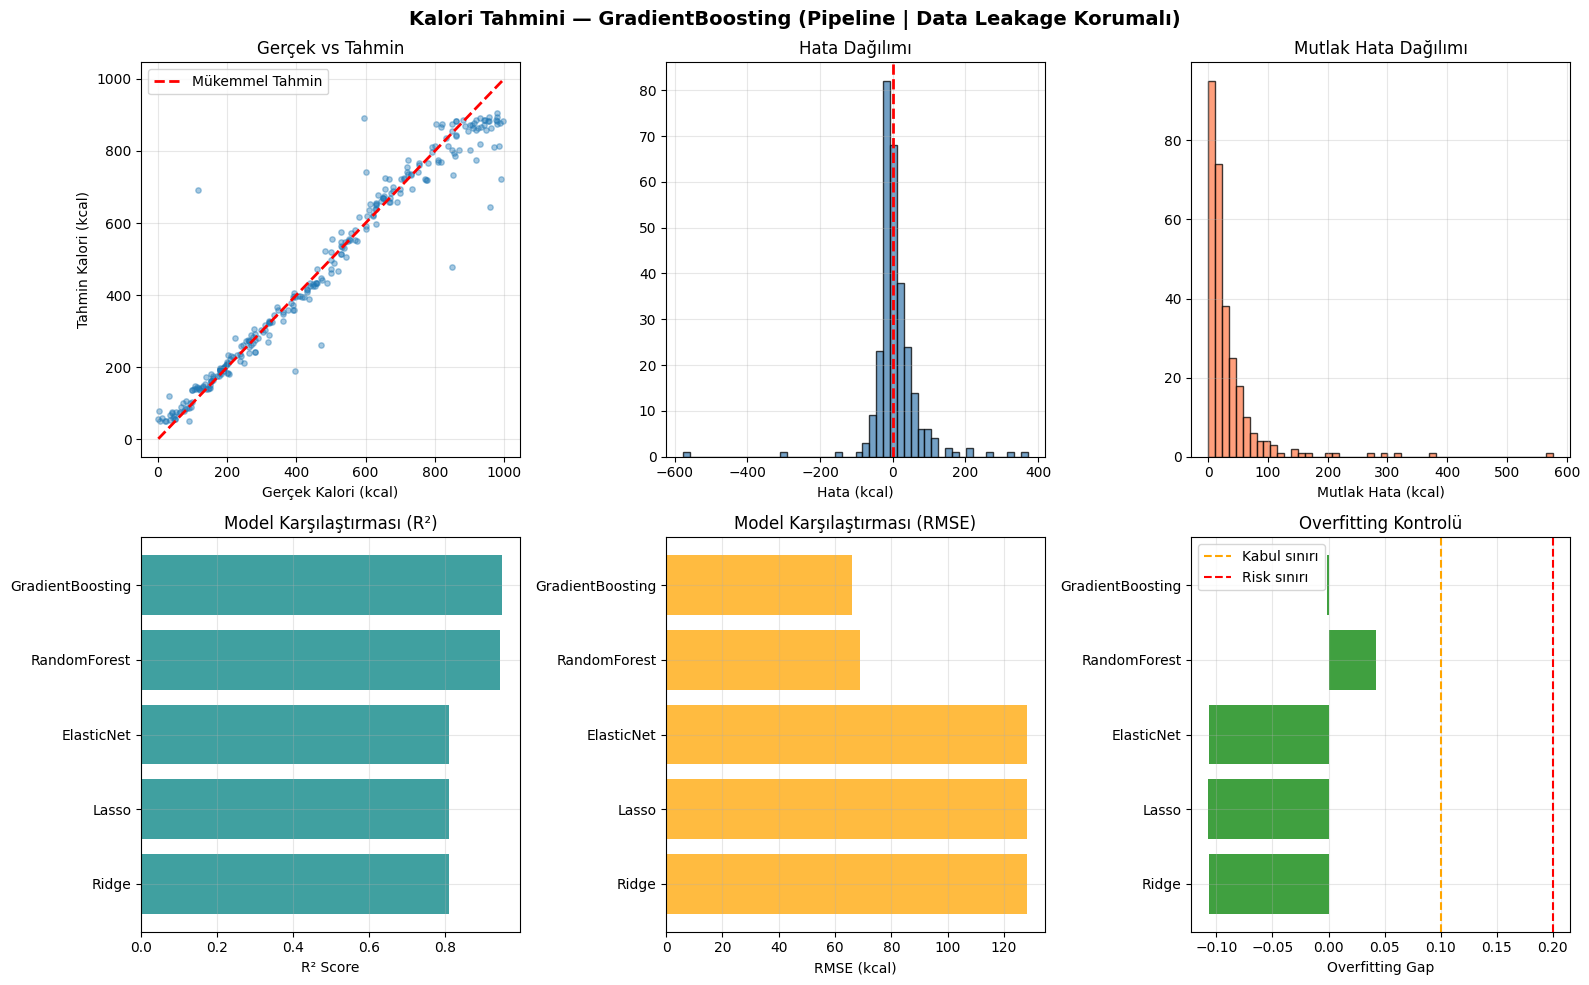

Exception ignored in: <function ResourceTracker.__del__ at 0x1054d5da0>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10761dda0>
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/m

In [ ]:
# ============================================================
# 7️⃣  EN İYİ MODELİ SEÇ
# ============================================================
print("\n" + "=" * 70)
print("[6/9] Model Karşılaştırması")
print("=" * 70)
 
comparison_df = pd.DataFrame([
    {
        "Model":        name,
        "Test_R2":      r["test_r2"],
        "Test_RMSE":    r["test_rmse"],
        "Test_MAE":     r["test_mae"],
        "CV_R2_Mean":   r["cv_r2_mean"],
        "CV_R2_Std":    r["cv_r2_std"],
        "Overfit_Gap":  r["train_r2"] - r["test_r2"],
    }
    for name, r in results.items()
])
 
print("\n📊 Model Performans Tablosu:\n")
print(comparison_df.to_string(index=False, float_format="{:.4f}".format))
 
best_name = comparison_df.loc[comparison_df["Test_R2"].idxmax(), "Model"]
best       = results[best_name]
best_pipe  = best["best_pipeline"]
best_preds = best["predictions"]
 
print(f"\n🏆 EN İYİ MODEL: {best_name}")
print(f"   Test R²   : {best['test_r2']:.4f}")
print(f"   Test RMSE : {best['test_rmse']:.2f} kcal")
print(f"   Test MAE  : {best['test_mae']:.2f} kcal")
 
# ============================================================
# 8️⃣  ÖZELLİK ÖNEMİ ANALİZİ
# ============================================================
print("\n[7/9] Özellik önemi analizi...")
 
estimator = best_pipe.named_steps["model"]
 
if hasattr(estimator, "feature_importances_"):
    fi_df = pd.DataFrame({
        "Feature":    FEATURE_NAMES,
        "Importance": estimator.feature_importances_,
    }).sort_values("Importance", ascending=False)
    print("\n📈 En Önemli 5 Özellik:\n")
    print(fi_df.head(5).to_string(index=False))
elif hasattr(estimator, "coef_"):
    fi_df = pd.DataFrame({
        "Feature":     FEATURE_NAMES,
        "Coefficient": np.abs(estimator.coef_),
    }).sort_values("Coefficient", ascending=False)
    print("\n📈 En Etkili 5 Özellik:\n")
    print(fi_df.head(5).to_string(index=False))
 
# ============================================================
# 9️⃣  GÖRSEL + SONUÇ KAYDET
# ============================================================
print("\n[8/9] Görselleştirmeler oluşturuluyor...")
 
errors     = y_test - best_preds
abs_errors = np.abs(errors)
pct_errors = abs_errors / y_test * 100
 
fig = plt.figure(figsize=(16, 10))
fig.suptitle(
    f"Kalori Tahmini — {best_name} (Pipeline | Data Leakage Korumalı)",
    fontsize=14, fontweight="bold",
)
 
ax1 = plt.subplot(2, 3, 1)
ax1.scatter(y_test, best_preds, alpha=0.4, s=15)
lim = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
ax1.plot(lim, lim, "r--", lw=2, label="Mükemmel Tahmin")
ax1.set_xlabel("Gerçek Kalori (kcal)")
ax1.set_ylabel("Tahmin Kalori (kcal)")
ax1.set_title("Gerçek vs Tahmin")
ax1.legend(); ax1.grid(alpha=0.3)
 
ax2 = plt.subplot(2, 3, 2)
ax2.hist(errors, bins=50, color="steelblue", alpha=0.75, edgecolor="black")
ax2.axvline(0, color="red", linestyle="--", lw=2)
ax2.set_xlabel("Hata (kcal)"); ax2.set_title("Hata Dağılımı")
ax2.grid(alpha=0.3)
 
ax3 = plt.subplot(2, 3, 3)
ax3.hist(abs_errors, bins=50, color="coral", alpha=0.75, edgecolor="black")
ax3.set_xlabel("Mutlak Hata (kcal)"); ax3.set_title("Mutlak Hata Dağılımı")
ax3.grid(alpha=0.3)
 
ax4 = plt.subplot(2, 3, 4)
ax4.barh(comparison_df["Model"], comparison_df["Test_R2"], color="teal", alpha=0.75)
ax4.set_xlabel("R² Score"); ax4.set_title("Model Karşılaştırması (R²)")
ax4.grid(alpha=0.3)
 
ax5 = plt.subplot(2, 3, 5)
ax5.barh(comparison_df["Model"], comparison_df["Test_RMSE"], color="orange", alpha=0.75)
ax5.set_xlabel("RMSE (kcal)"); ax5.set_title("Model Karşılaştırması (RMSE)")
ax5.grid(alpha=0.3)
 
ax6 = plt.subplot(2, 3, 6)
colors = [
    "green" if g < 0.1 else "orange" if g < 0.2 else "red"
    for g in comparison_df["Overfit_Gap"]
]
ax6.barh(comparison_df["Model"], comparison_df["Overfit_Gap"], color=colors, alpha=0.75)
ax6.axvline(0.1, color="orange", linestyle="--", label="Kabul sınırı")
ax6.axvline(0.2, color="red",    linestyle="--", label="Risk sınırı")
ax6.set_xlabel("Overfitting Gap"); ax6.set_title("Overfitting Kontrolü")
ax6.legend(); ax6.grid(alpha=0.3)
 
plt.tight_layout()
plt.savefig("kalori_tahmin_analiz.png", dpi=150, bbox_inches="tight")
print("✅ Grafik: kalori_tahmin_analiz.png")
 
# CSV kayıtları
print("\n[9/9] CSV dosyaları kaydediliyor...")
 
pd.DataFrame({
    "Gercek_Kalori":  y_test,
    "Tahmin_Kalori":  best_preds,
    "Hata":           errors,
    "Mutlak_Hata":    abs_errors,
    "Yuzde_Hata":     pct_errors,
}).to_csv("kalori_tahmin_sonuclari.csv", index=False, encoding="utf-8-sig")
 
comparison_df.to_csv("model_karsilastirma.csv", index=False, encoding="utf-8-sig")
 
pd.DataFrame([{
    "En_Iyi_Model":        best_name,
    "Best_Params":         str(best["best_params"]),
    "Test_R2":             best["test_r2"],
    "Test_RMSE":           best["test_rmse"],
    "Test_MAE":            best["test_mae"],
    "CV_R2_Mean":          best["cv_r2_mean"],
    "CV_R2_Std":           best["cv_r2_std"],
    "Ortalama_Yuzde_Hata": pct_errors.mean(),
}]).to_csv("model_performans_ozeti.csv", index=False, encoding="utf-8-sig")
 
print("✅ kalori_tahmin_sonuclari.csv")
print("✅ model_karsilastirma.csv")
print("✅ model_performans_ozeti.csv")
 
# ============================================================
# ÖZET RAPOR
# ============================================================
print("\n" + "=" * 70)
print("📊 ÖZET RAPOR")
print("=" * 70)
print(f"\n✅ En İyi Model    : {best_name}")
print(f"✅ Best Params     : {best['best_params']}")
print(f"✅ Test R²         : {best['test_r2']:.4f}")
print(f"✅ Test RMSE       : {best['test_rmse']:.2f} kcal")
print(f"✅ Test MAE        : {best['test_mae']:.2f} kcal")
print(f"✅ CV R² (5-fold)  : {best['cv_r2_mean']:.4f} ± {best['cv_r2_std']:.4f}")
print(f"✅ Ort. % Hata     : {pct_errors.mean():.2f}%")
 
r2 = best["test_r2"]
emoji = "🟢 Mükemmel" if r2 > 0.9 else ("🟢 Çok iyi" if r2 > 0.8 else
        ("🟡 Kabul edilebilir" if r2 > 0.7 else "🔴 İyileştirme gerekli"))
print(f"\n📌 Model Yorumu: {emoji}")
 
gap = best["train_r2"] - best["test_r2"]
tag = "✅ Overfitting YOK" if gap < 0.1 else ("⚠️ Hafif overfit" if gap < 0.2 else "❌ Ciddi overfit")
print(f"📌 Overfit Gap  : {gap:.3f}  →  {tag}")
 
print("\n📌 Data Leakage Koruması:")
print("   ✅ Train/Test bölme → feature engineering'den ÖNCE")
print("   ✅ Scaler Pipeline içinde → CV fold'larına sızmaz")
print("   ✅ theoretical_energy feature olarak kullanılmadı")
print("   ✅ GridSearchCV Pipeline üzerinde → tüm arama sızdırmaz")
 
print("\n" + "=" * 70)
print("✅ ANALİZ TAMAMLANDI!")
print("=" * 70)
 
